# Notebook 06 — Exploratory Analysis and SQL Queries

## Purpose
I explore the data visually and with SQL queries before any modelling.
I look for patterns, outliers, and answers to the descriptive business questions.

## Why this matters
EDA guides hypothesis refinement and feature selection.  SQL queries produce
the business-level summaries that go in the report.

## Inputs
`data/processed/master.parquet`

## Outputs
Figures saved to `reports/figures/` and `paper_or_report/figures/`
Tables saved to `reports/tables/` and `paper_or_report/tables/`


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.visualization import (
    plot_review_distribution, plot_monthly_revenue,
    plot_delivery_delay_hist, plot_revenue_by_state, save_fig,
)
from src.sql_queries import (
    get_revenue_by_state, get_top_categories, get_monthly_revenue,
    get_delivery_performance_by_state, get_payment_type_breakdown,
    get_delay_vs_review, get_repeat_purchase_rate,
    get_late_orders_by_category,
)
from src.utils import save_table

cfg   = load_config()
paths = Paths(cfg)

master = pd.read_parquet(paths.processed / cfg['data']['master_file'])
print(f"Master loaded: {master.shape}")


Master loaded: (96478, 33)


In [2]:
# Connect DuckDB and register master as a SQL table
# DuckDB is in-process — no server needed
con = duckdb.connect()
con.register('master', master)
print("DuckDB connected. 'master' table registered.")
print()
print("Quick SQL test:")
test = con.execute("SELECT COUNT(*) as n_orders FROM master").df()
print(test)


DuckDB connected. 'master' table registered.

Quick SQL test:
   n_orders
0     96478


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\review_distribution.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\review_distribution.png


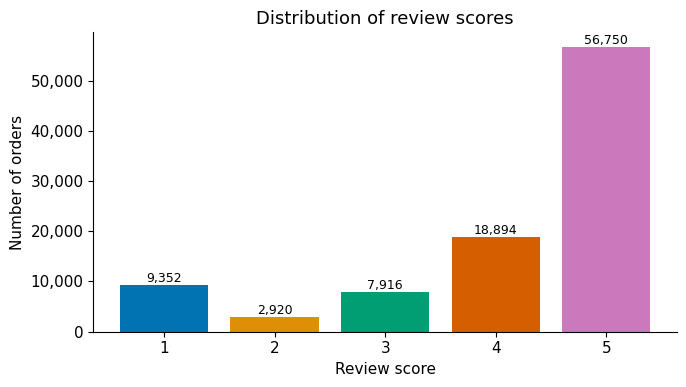

In [3]:
# --- CHART 1: Review distribution ---
fig = plot_review_distribution(master,
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\monthly_revenue.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\monthly_revenue.png


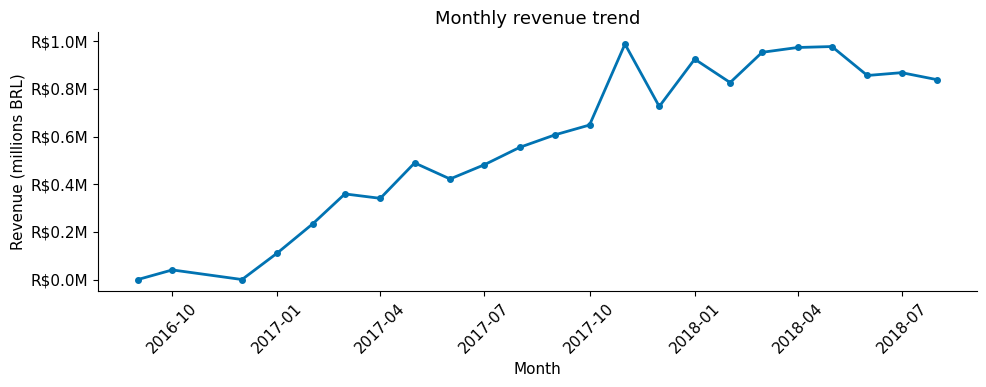

In [4]:
# --- CHART 2: Monthly revenue trend ---
fig = plot_monthly_revenue(master,
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\delivery_delay_hist.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\delivery_delay_hist.png


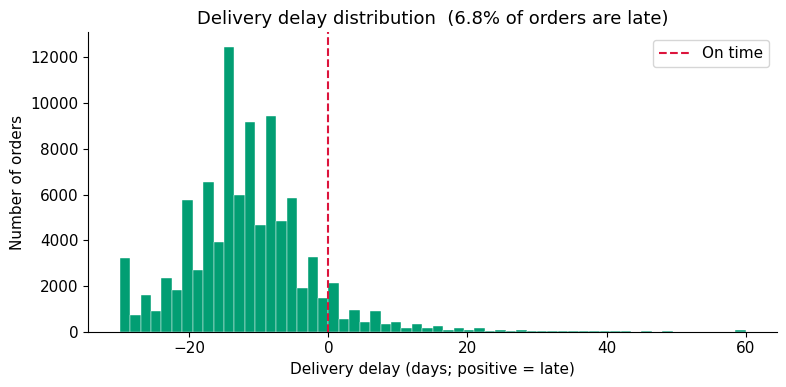

In [5]:
# --- CHART 3: Delivery delay histogram ---
fig = plot_delivery_delay_hist(master,
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\revenue_by_state.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\revenue_by_state.png


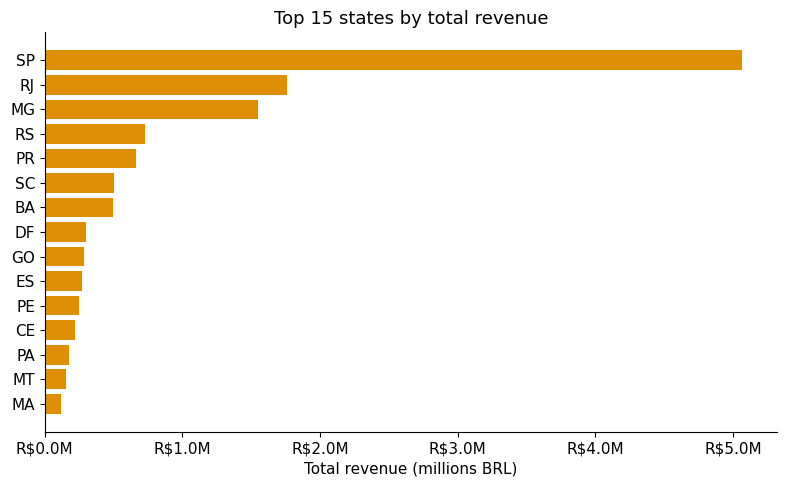

In [6]:
# --- CHART 4: Revenue by state ---
fig = plot_revenue_by_state(master,
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


In [7]:
# --- SQL 1: Revenue by state ---
print("=== Revenue by State (SQL) ===")
rev_state = get_revenue_by_state(con)
print(rev_state.head(10).to_string(index=False))
save_table(rev_state, 'revenue_by_state',
           reports_dir=str(paths.reports_tabs),
           paper_dir=str(paths.paper_tabs))


=== Revenue by State (SQL) ===
customer_state  total_revenue_brl  num_orders  avg_order_value  revenue_share_pct
            SP         5067633.16       40501           125.12              38.33
            RJ         1759651.13       12350           142.48              13.31
            MG         1552481.83       11354           136.73              11.74
            RS          728897.47        5345           136.37               5.51
            PR          666063.51        4923           135.30               5.04
            SC          507012.13        3546           142.98               3.83
            BA          493584.14        3256           151.59               3.73
            DF          296498.41        2080           142.55               2.24
            GO          282836.70        1957           144.53               2.14
            ES          268643.45        1995           134.66               2.03
  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects

[WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/reports/tables/revenue_by_state.csv'),
 WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/paper_or_report/tables/revenue_by_state.csv')]

In [8]:
# --- SQL 2: Top product categories ---
print("=== Top Categories (SQL) ===")
top_cats = get_top_categories(con, top_n=15)
print(top_cats.to_string(index=False))
save_table(top_cats, 'top_categories',
           reports_dir=str(paths.reports_tabs),
           paper_dir=str(paths.paper_tabs))


=== Top Categories (SQL) ===
product_category_english  total_revenue_brl  num_orders  avg_order_value  avg_review_score  avg_delivery_delay_days
           health_beauty         1232074.12        8608           143.13             4.235                   -11.96
           watches_gifts         1163585.35        5472           212.64             4.127                   -11.77
          bed_bath_table         1022202.47        9167           111.51             4.010                   -11.35
          sports_leisure          956122.87        7491           127.64             4.233                   -11.84
   computers_accessories          887181.15        6501           136.47             4.083                   -12.36
         furniture_decor          715568.48        6213           115.17             4.073                   -12.28
              housewares          617564.75        5688           108.57             4.204                   -12.04
              cool_stuff          611226.51

[WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/reports/tables/top_categories.csv'),
 WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/paper_or_report/tables/top_categories.csv')]

In [9]:
# --- SQL 3: Delivery delay vs review score ---
print("=== Delivery Delay vs Review Score (SQL) ===")
delay_review = get_delay_vs_review(con)
print(delay_review.to_string(index=False))
print()
print("Interpretation: This table is consistent with H2 — later deliveries")
print("are associated with lower average review scores.")
save_table(delay_review, 'delay_vs_review',
           reports_dir=str(paths.reports_tabs),
           paper_dir=str(paths.paper_tabs))


=== Delivery Delay vs Review Score (SQL) ===
      delay_bucket  num_orders  avg_review_score  std_review_score
Very early (< -7d)       70929             4.317             1.138
 Early (-7 to -1d)       17234             4.200             1.182
      On time (0d)        1280             4.034             1.252
       Late (1-7d)        3600             2.715             1.660
      Late (8-14d)        1446             1.671             1.212
  Very late (>14d)        1335             1.723             1.252

Interpretation: This table is consistent with H2 — later deliveries
are associated with lower average review scores.
  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\tables\delay_vs_review.csv
  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\tables\delay_vs_review.csv


[WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/reports/tables/delay_vs_review.csv'),
 WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/paper_or_report/tables/delay_vs_review.csv')]

In [10]:
# --- SQL 4: Payment type breakdown ---
print("=== Payment Type Breakdown (SQL) ===")
pay = get_payment_type_breakdown(con)
print(pay.to_string(index=False))


=== Payment Type Breakdown (SQL) ===
payment_type  num_orders  total_revenue_brl  avg_order_value  avg_installments  order_share_pct
 credit_card       73941        10539760.33           142.54              3.51            76.64
      boleto       19191         2329807.64           121.40              1.00            19.89
     voucher        1861          173926.71            93.46              1.12             1.93
  debit_card        1484          177868.46           119.86              1.00             1.54


In [11]:
# --- SQL 5: Repeat purchase rate ---
print("=== Repeat Purchase Rate (SQL) ===")
rpr = get_repeat_purchase_rate(con)
print(rpr.to_string(index=False))
repeat_rate = float(rpr['repeat_rate_pct'].iloc[0])
print(f"\nInterpretation: {repeat_rate:.1f}% of customers placed more than one order.")
print("This is relatively low, suggesting customer retention is a key opportunity.")


=== Repeat Purchase Rate (SQL) ===
 total_customers  repeat_customers  repeat_rate_pct  avg_orders_per_customer
           93358            2801.0              3.0                    1.033

Interpretation: 3.0% of customers placed more than one order.
This is relatively low, suggesting customer retention is a key opportunity.


In [12]:
# --- Correlation: delivery delay vs review score ---
from scipy import stats
valid = master.dropna(subset=['delivery_delay_days', 'review_score'])
r, p = stats.spearmanr(valid['delivery_delay_days'], valid['review_score'])
print(f"Spearman correlation (delivery_delay vs review_score):")
print(f"  rho = {r:.4f},  p-value = {p:.2e}")
print()
if p < 0.05:
    direction = "negative" if r < 0 else "positive"
    print(f"  This is statistically significant (p < 0.05).")
    print(f"  Direction is {direction}, which is {'consistent' if r < 0 else 'inconsistent'} with H2.")
    print("  I interpret this cautiously: correlation does not imply causation.")


Spearman correlation (delivery_delay vs review_score):
  rho = -0.1764,  p-value = 0.00e+00

  This is statistically significant (p < 0.05).
  Direction is negative, which is consistent with H2.
  I interpret this cautiously: correlation does not imply causation.


In [ ]:
print("Notebook 06 complete.")
print("Next: Notebook 07 — RFM Analysis and Customer Segmentation")
